In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# First Video

In [2]:
def convert_color(image):
    return cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

In [3]:
capture=cv2.VideoCapture(r'vtest.avi')

In [4]:
capture.get(cv2.CAP_PROP_FRAME_COUNT)

795.0

In [5]:
random_frames=capture.get(cv2.CAP_PROP_FRAME_COUNT)*np.random.uniform(size=30)  # get 30 random frames

In [8]:
frames=[]
for frame_id in random_frames:
    capture.set(cv2.CAP_PROP_FRAME_COUNT,frame_id)
    ret,frame=capture.read()
    frames.append(frame)
capture.release()

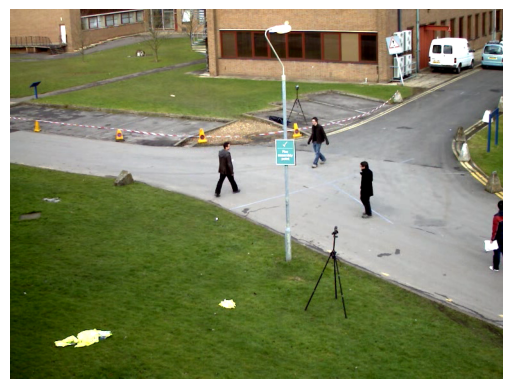

In [13]:
plt.imshow(convert_color(frames[10]))
plt.axis('off')
plt.show()

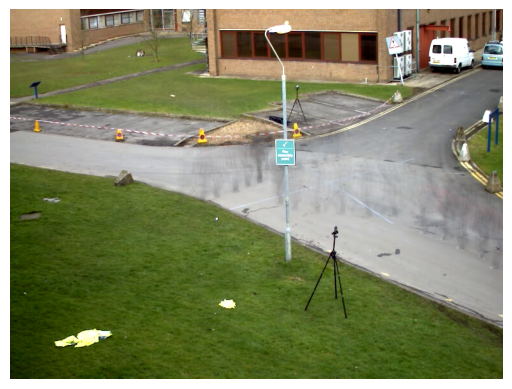

In [16]:
frame_avg=np.average(frames,axis=0).astype(np.uint8)
plt.imshow(convert_color(frame_avg))
plt.axis('off')
plt.show()

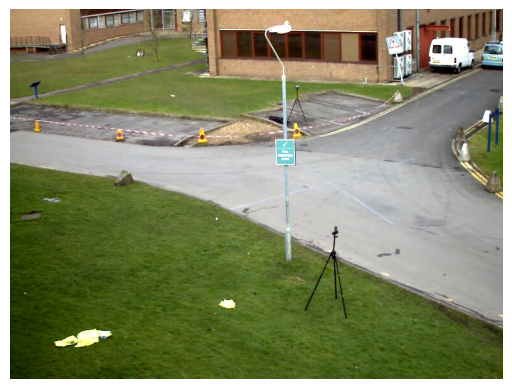

In [17]:
frame_median=np.median(frames,axis=0).astype(np.uint8)
plt.imshow(convert_color(frame_median))
plt.axis('off')
plt.show()

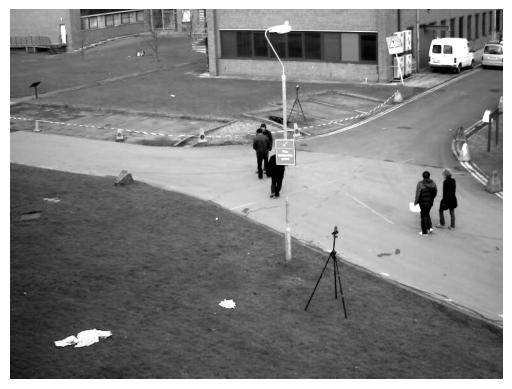

In [22]:
frame1=frames[29]
gray_frame=cv2.cvtColor(frame1,cv2.COLOR_BGR2GRAY)
plt.imshow(gray_frame,cmap='gray')
plt.axis('off')
plt.show()

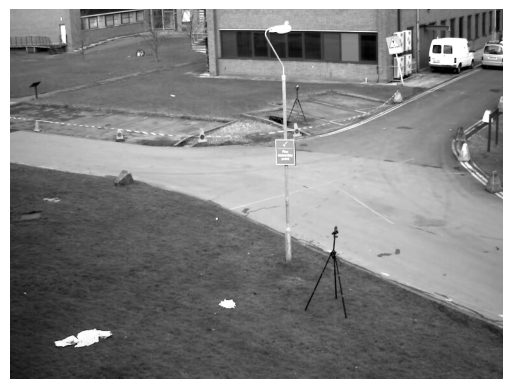

In [23]:
fram_median = np.median(frames, axis=0).astype(np.uint8)
gray_background = cv2.cvtColor(fram_median, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_background, cmap='gray')
plt.axis('off')
plt.show()

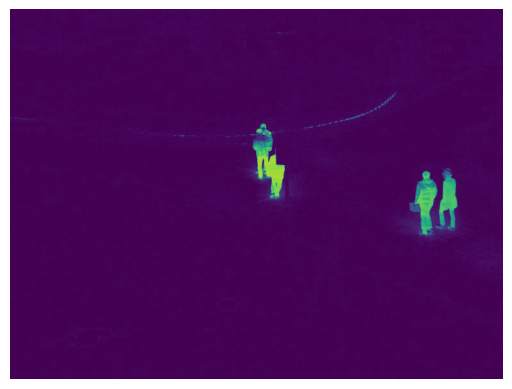

In [24]:
background_remove=cv2.absdiff(gray_frame,gray_background)
plt.imshow(background_remove)
plt.axis('off')
plt.show()

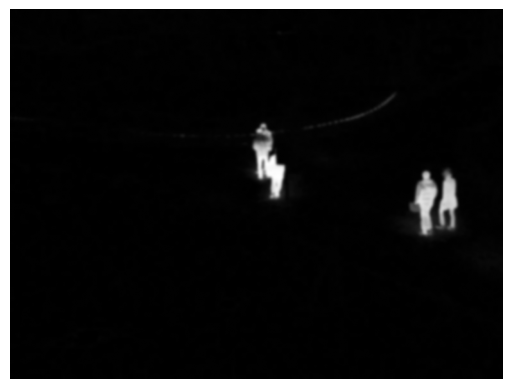

In [27]:
frame_blur=cv2.GaussianBlur(background_remove,(11,11),0)
plt.imshow(frame_blur,cmap='gray')
plt.axis('off')
plt.show()

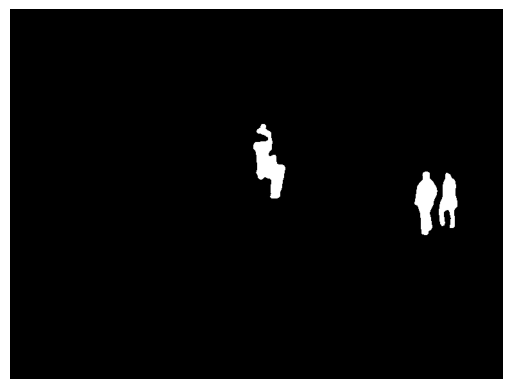

In [28]:
_,frames_trs=cv2.threshold(frame_blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(convert_color(frames_trs), cmap='gray')
plt.axis('off')
plt.show()

In [29]:
(contours, _) = cv2.findContours(frames_trs, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

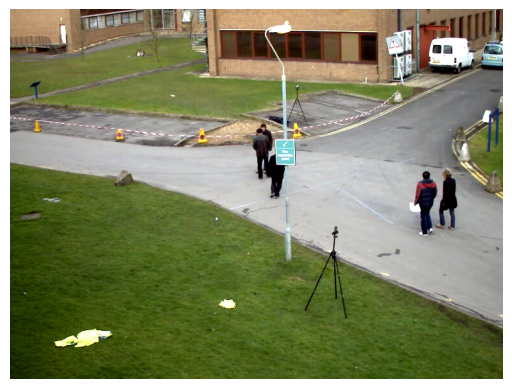

In [30]:
plt.imshow(convert_color(frame1))
plt.axis('off')
plt.show()

In [31]:
for contour in contours:
    x,y,w,h = cv2.boundingRect(contour)
    cv2.rectangle(frame1, (x,y), (x+w, y+h), (0,0,255), 2)

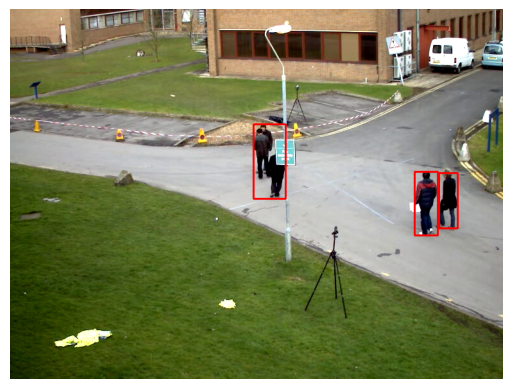

In [32]:
plt.imshow(convert_color(frame1))
plt.axis('off')
plt.show()

## Second Video

In [34]:
captures = cv2.VideoCapture(r"background video _ people _ walking _.mp4")
background_sub = cv2.createBackgroundSubtractorMOG2()


while captures.isOpened():
    ret, frame = captures.read()
    if not ret:
        break
    
    fg_mask = background_sub.apply(frame)
    (contours, _) = cv2.findContours(fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        if cv2.contourArea(contour) >500 :
            x,y,w,h = cv2.boundingRect(contour)
            cv2.rectangle(frame, (x,y), (x+w, y+h), (0,0,255), 1)
    cv2.imshow("Original Frame", frame)
    cv2.imshow("Foreground Mask", fg_mask)
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break
captures.release()
cv2.destroyAllWindows()